# Fatores Socioeconômicos no Desempenho do ENEM × Indicadores Estaduais do IBGE
**Entrega 2: Pré-processamento, Modelagem Preditiva e Avaliação**

**Pergunta do projeto:** quanto do desempenho no ENEM 2023 é explicado pela origem socioeconômica do aluno (renda familiar, tipo de escola, escolaridade dos pais, acesso a computador e internet) e pelo contexto do estado onde ele fez a prova (IDHM)?

**O que esta entrega acrescenta à Entrega 1:**
1. EDA complementar: moda, outliers por IQR e correlações.
2. Feature engineering a partir do questionário socioeconômico.
3. Pré-processamento sem vazamento: `Pipeline` + `ColumnTransformer`, com One-Hot e `StandardScaler`.
4. **Regressão Linear** para prever a `NOTA_FINAL`.
5. **Regressão Logística, Árvore de Decisão e KNN** para classificar alunos com `NOTA_FINAL > 700`.
6. Avaliação com validação cruzada, precisão, recall, F1, matriz de confusão e análise de overfitting.

**Dados:** amostra estratificada por UF (4%, `SEED = 42`) dos concluintes do ensino médio no ENEM 2023 (INEP) + indicadores estaduais (IBGE e PNUD). A coleta é feita por `baixar_dados.py`. As funções compartilhadas com a Entrega 1 estão em `src/`.

Os gráficos continuam a numeração da Entrega 1, que tem os Gráficos 1 a 5. Aqui vão do 6 ao 14.

## 1. Configuração e importações

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import (GridSearchCV, KFold, StratifiedKFold, cross_validate,
                                     train_test_split, validation_curve)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Módulos do projeto
from src.dados import ARQ_AMOSTRA, ARQ_META_AMOSTRA, COLS_NOTAS, SEED, carregar_dados, etl, recorte_presentes
from src.estilo import (AZUL, CMAP_DIVERGENTE, CORES_MODELOS, DESTAQUE, LARANJA,
                        TINTA_SECUNDARIA, aplicar_estilo)
from src.features import LIMIAR_ALTO_DESEMPENHO, criar_features, flag_outliers_iqr
from src.kpis import calcular_kpis, exibir_kpis
from src.modelagem import (formatar_parametros, metricas_classificacao, metricas_regressao,
                           montar_preprocessador, resumo_cv, tabela_coeficientes, taxa_base)

warnings.filterwarnings("ignore")

# True = microdados reais (INEP + IBGE) | False = simulação (fallback, com menos variáveis)
USAR_DADOS_REAIS = True
ARQ_RESULTADOS = Path("resultados/metricas_entrega2.json")

# Reprodutibilidade: SEED = 42 em toda rotina aleatória (split, CV, árvore, undersampling)
np.random.seed(SEED)

aplicar_estilo()
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
pd.set_option("display.max_columns", 40)

## 2. Coleta de dados
*Conceito 1: Coleta de Dados*

| Base | Fonte | Recorte | Como foi coletada |
|---|---|---|---|
| Microdados do ENEM 2023 | INEP | 3.933.955 inscritos → concluintes de 2023 com escola informada → amostra de 4% por UF | `baixar_dados.py`: download do `.zip`, leitura do CSV em blocos (`chunksize`), filtros e amostragem estratificada |
| Indicadores estaduais | IBGE (Censo 2022, PNAD Contínua 2023) e PNUD (IDHM 2023) | 27 UFs | API do SIDRA + Tabela 5 do Radar IDHM, em `dados/ibge_uf.csv` |

**Por que ENEM 2023?** A partir de 2024, o INEP publica notas e questionário em arquivos sem chave de ligação, o que impede cruzar renda com nota no nível do aluno (detalhes em `docs/DECISOES.md`).

In [2]:
df_ibge, df_enem = carregar_dados(USAR_DADOS_REAIS)

if USAR_DADOS_REAIS:
    meta = json.loads(ARQ_META_AMOSTRA.read_text(encoding="utf-8"))
    rotulos = {"linhas_lidas": "Inscritos no ENEM 2023 (CSV completo)",
               "concluintes_2023": "Concluintes do ensino médio em 2023",
               "nao_treineiros": "… e não treineiros",
               "escola_informada": "… e com escola pública/privada informada (universo)"}
    funil = pd.Series({rotulos[k]: v for k, v in meta["funil"].items()})
    funil[f"Amostra estratificada ({meta['fracao_por_uf']:.0%} de cada UF)"] = meta["linhas_amostra"]
    display(funil.to_frame("Registros").style.format("{:,}"))

print(f"ENEM (amostra): {df_enem.shape[0]:,} linhas × {df_enem.shape[1]} colunas | IBGE: {df_ibge.shape[0]} UFs")

,Registros
Inscritos no ENEM 2023 (CSV completo),"3,933,955"
Concluintes do ensino médio em 2023,"1,401,164"
… e não treineiros,"1,401,164"
… e com escola pública/privada informada (universo),"1,401,159"
Amostra estratificada (4% de cada UF),"56,048"


ENEM (amostra): 56,048 linhas × 18 colunas | IBGE: 27 UFs


## 3. Limpeza e pré-processamento
*Conceito 2: Limpeza, tratamento de ausentes, integração e transformação*

Etapas:
1. **Duplicatas:** cada inscrição (`NU_INSCRICAO`) deve aparecer uma única vez.
2. **Domínio das notas:** todas devem estar entre 0 e 1000.
3. **ETL** (`etl()` em `src/dados.py`): diagnóstico de nulos → **integração** ENEM × IBGE (merge `m:1` validado) → `NOTA_FINAL` (média das 5 provas) → `FAIXA_RENDA` e `RENDA_IDX` a partir do `Q006`.
4. **Ausentes:** classificar cada nulo como *estrutural* (o aluno faltou ou foi eliminado, então não há nota a imputar) ou *acidental* (presente sem nota).
5. **Consistência da redação:** nota zero na redação deve corresponder a uma situação diferente de "Sem problemas".

A **normalização** (padronização z-score com `StandardScaler`) e a imputação de ausentes nas *features* ficam no `Pipeline` da Seção 7, para serem aprendidas só no treino.

In [3]:
# 3.1 Duplicatas
if USAR_DADOS_REAIS:
    n_duplicadas = pd.read_parquet(ARQ_AMOSTRA, columns=["NU_INSCRICAO"])["NU_INSCRICAO"].duplicated().sum()
else:
    n_duplicadas = df_enem.duplicated().sum()
print(f"Inscrições duplicadas: {n_duplicadas}")

# 3.2 Notas fora do intervalo [0, 1000]
fora_do_dominio = ((df_enem[COLS_NOTAS] < 0) | (df_enem[COLS_NOTAS] > 1000)).sum().sum()
assert fora_do_dominio == 0, "Há notas fora de [0, 1000]"
print(f"Notas fora de [0, 1000]: {fora_do_dominio}\n")

# 3.3 ETL: diagnóstico de nulos, integração com o IBGE e variáveis derivadas
df = etl(df_enem, df_ibge)
df_pres = recorte_presentes(df)

# 3.4 Natureza dos nulos: entre os presentes, quantas notas faltam?
nulos_acidentais = int(df.loc[df["PRESENTE"], COLS_NOTAS].isna().any(axis=1).sum())
nulos_estruturais = int(df.loc[~df["PRESENTE"], COLS_NOTAS].isna().any(axis=1).sum())
print(f"Alunos sem alguma nota por falta/eliminação (estrutural): {nulos_estruturais:,}")
print(f"Alunos presentes sem alguma nota (acidental):             {nulos_acidentais:,}")
print(f"Recorte de desempenho (presentes com as 5 notas): {len(df_pres):,} de {len(df):,} ({len(df_pres)/len(df):.1%})")

# 3.5 Consistência: redação zerada × situação da redação (1 = sem problemas)
if "TP_STATUS_REDACAO" in df_pres:
    zerada = df_pres["NU_NOTA_REDACAO"] == 0
    display(pd.crosstab(df_pres["TP_STATUS_REDACAO"], zerada.map({True: "nota 0", False: "nota > 0"}))
            .rename_axis(index="TP_STATUS_REDACAO (1 = sem problemas)", columns=None))

Inscrições duplicadas: 0
Notas fora de [0, 1000]: 0

Nulos por coluna (antes do tratamento):
NU_NOTA_CN           13841
NU_NOTA_CH           12034
NU_NOTA_LC           12034
NU_NOTA_MT           13841
NU_NOTA_REDACAO      12034
TP_STATUS_REDACAO    12034 

Alunos sem alguma nota por falta/eliminação (estrutural): 14,016
Alunos presentes sem alguma nota (acidental):             0
Recorte de desempenho (presentes com as 5 notas): 42,032 de 56,048 (75.0%)


,nota 0,nota > 0
TP_STATUS_REDACAO (1 = sem problemas),,
1,0,40304
2,14,0
3,464,0
4,745,0
6,335,0
7,14,0
8,126,0
9,30,0


## 4. Estatísticas descritivas complementares
*Conceito 3: média, mediana, moda e desvio padrão*

A Entrega 1 já apresentou `describe()`. Aqui acrescentamos a **moda** e a análise de **outliers por IQR**.

*Nota sobre a moda:* as notas objetivas do ENEM são calculadas por TRI e são praticamente contínuas, então quase nenhum valor exato se repete. Para que a moda tenha sentido, ela é calculada sobre as notas **arredondadas para inteiro**. A redação só assume múltiplos de 20, então nela a moda é exata.

In [4]:
cols_desc = COLS_NOTAS + ["NOTA_FINAL"]
notas = df_pres[cols_desc]
moda = pd.Series({c: (notas[c] if c == "NU_NOTA_REDACAO" else notas[c].round()).mode().iloc[0] for c in cols_desc})

# Classe modal: intervalo de 20 pontos com mais alunos (mais estável que a moda em notas contínuas)
faixas = np.arange(0, 1001, 20)
classe_modal = pd.Series({c: pd.cut(notas[c], faixas, include_lowest=True).value_counts().idxmax() for c in cols_desc})

tabela_desc = pd.DataFrame({
    "Média": notas.mean(), "Mediana": notas.median(), "Moda": moda,
    "Classe modal": classe_modal.map(lambda iv: f"{iv.left:.0f}–{iv.right:.0f}"),
    "Desvio padrão": notas.std(), "Mínimo": notas.min(), "Máximo": notas.max(),
})
display(tabela_desc.style.format({c: "{:,.1f}" for c in ["Média", "Mediana", "Moda", "Desvio padrão", "Mínimo", "Máximo"]}))

# Quando a moda cai em 0, ela reflete as provas zeradas (único valor que se repete muito), não o centro da distribuição
modas_zero = [c for c in cols_desc if moda[c] == 0]
if modas_zero:
    display(Markdown("**Moda igual a 0 em " + ", ".join(f"`{c}` ({(notas[c] == 0).sum()} alunos zerados)" for c in modas_zero)
                     + ":** em notas contínuas, quase nenhum valor se repete, e o zero (prova em branco ou anulada) acaba sendo o mais "
                       "frequente. A classe modal mostra onde de fato se concentra a maioria dos alunos. Por isso, nas provas "
                       "objetivas, média e mediana são medidas de tendência central mais adequadas que a moda."))

# Moda das variáveis categóricas (base completa)
cats = ["TP_ESCOLA", "FAIXA_RENDA", "Q006", "REGIAO", "UF"]
moda_cat = pd.DataFrame({
    "Moda": [df[c].mode().iloc[0] for c in cats],
    "% da base": [df[c].value_counts(normalize=True).iloc[0] * 100 for c in cats],
}, index=cats)
display(moda_cat.style.format({"% da base": "{:.1f}%"}))

,Média,Mediana,Moda,Classe modal,Desvio padrão,Mínimo,Máximo
NU_NOTA_CN,489.0,486.6,450.0,440–460,84.5,0.0,843.4
NU_NOTA_CH,518.3,524.3,554.0,520–540,85.1,0.0,799.5
NU_NOTA_LC,514.5,519.3,532.0,520–540,73.5,0.0,768.9
NU_NOTA_MT,530.7,519.1,0.0,400–420,128.6,0.0,958.6
NU_NOTA_REDACAO,628.7,640.0,560.0,540–560,215.0,0.0,980.0
NOTA_FINAL,536.2,535.9,538.0,520–540,95.8,57.6,820.4


**Moda igual a 0 em `NU_NOTA_MT` (204 alunos zerados):** em notas contínuas, quase nenhum valor se repete, e o zero (prova em branco ou anulada) acaba sendo o mais frequente. A classe modal mostra onde de fato se concentra a maioria dos alunos. Por isso, nas provas objetivas, média e mediana são medidas de tendência central mais adequadas que a moda.

,Moda,% da base
TP_ESCOLA,Pública,83.4%
FAIXA_RENDA,Baixa Renda,65.8%
Q006,B,32.3%
REGIAO,Sudeste,34.6%
UF,SP,18.1%


### 4.1 Outliers pelo critério IQR
Um valor é sinalizado como outlier quando fica fora de **[Q1 − 1,5·IQR, Q3 + 1,5·IQR]**.

**Decisão:** os outliers são **sinalizados** (coluna `OUTLIER_IQR`) e **mantidos** na análise.
- As notas estão todas no domínio válido [0, 1000] (Seção 3), então não há erro de digitação.
- Os valores extremos são resultados reais: redações anuladas (nota 0) e provas objetivas com desempenho muito baixo ou muito alto.
- Remover esses alunos esconderia justamente os grupos que o projeto quer entender (por exemplo, os de alto desempenho, a classe positiva da Seção 9).

,Limite inferior,Limite superior,Outliers,% outliers
Variável,,,,
NU_NOTA_CN,269.7,708.6,459,1.09%
NU_NOTA_CH,292.5,749.3,81,0.19%
NU_NOTA_LC,319.9,714.3,370,0.88%
NU_NOTA_MT,135.4,918.1,245,0.58%
NU_NOTA_REDACAO,100.0,1220.0,"1,734",4.13%
NOTA_FINAL,273.4,801.7,157,0.37%


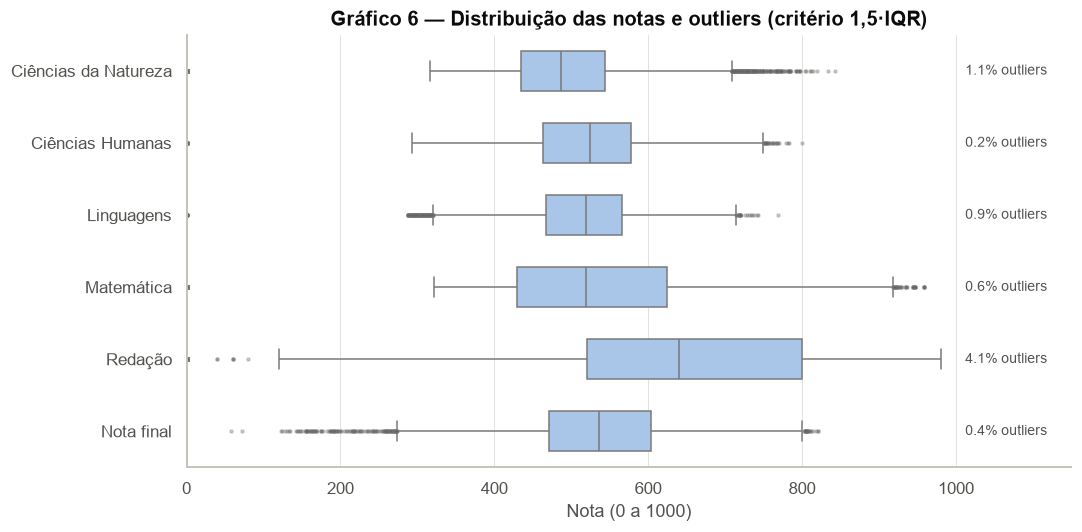

In [5]:
linhas = []
for c in cols_desc:
    mascara, lim_inf, lim_sup = flag_outliers_iqr(df_pres[c])
    linhas.append({"Variável": c, "Limite inferior": lim_inf, "Limite superior": lim_sup,
                   "Outliers": int(mascara.sum()), "% outliers": mascara.mean() * 100})
tabela_outliers = pd.DataFrame(linhas).set_index("Variável")
display(tabela_outliers.style.format({"Limite inferior": "{:.1f}", "Limite superior": "{:.1f}",
                                       "Outliers": "{:,}", "% outliers": "{:.2f}%"}))

# Sinalização (sem remoção) a partir da NOTA_FINAL
df_pres["OUTLIER_IQR"] = flag_outliers_iqr(df_pres["NOTA_FINAL"])[0]

# ---------- Gráfico 6 — boxplots das provas (bigodes = 1,5·IQR) ----------
rotulos_provas = {"NU_NOTA_CN": "Ciências da Natureza", "NU_NOTA_CH": "Ciências Humanas",
                  "NU_NOTA_LC": "Linguagens", "NU_NOTA_MT": "Matemática",
                  "NU_NOTA_REDACAO": "Redação", "NOTA_FINAL": "Nota final"}
longo = df_pres[cols_desc].rename(columns=rotulos_provas).melt(var_name="Prova", value_name="Nota")

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=longo, y="Prova", x="Nota", color="#9ec5f4", whis=1.5, width=0.55, linewidth=1,
            flierprops={"marker": "o", "markersize": 2, "alpha": 0.3, "markerfacecolor": TINTA_SECUNDARIA},
            ax=ax)
for i, c in enumerate(cols_desc):
    ax.text(1012, i, f"{tabela_outliers.loc[c, '% outliers']:.1f}% outliers", va="center", fontsize=9,
            color=TINTA_SECUNDARIA)
ax.set(title="Gráfico 6 — Distribuição das notas e outliers (critério 1,5·IQR)",
       xlabel="Nota (0 a 1000)", ylabel="", xlim=(0, 1150))
plt.tight_layout(); plt.show()

## 5. Indicadores (KPIs)
*Conceito 4: Definição e construção de indicadores*

Os mesmos **20 KPIs** da Entrega 1, em 4 eixos (desempenho, perfil socioeconômico, cruzamento com o IBGE e operacional), calculados por `calcular_kpis()` em `src/kpis.py` sobre os dados reais. Os gráficos dos KPIs (1 a 5) estão no notebook da Entrega 1.

In [6]:
df_kpis, aux = calcular_kpis(df, df_pres, df_ibge)
assert len(df_kpis) == 20, f"Esperados 20 KPIs, encontrados {len(df_kpis)}"
exibir_kpis(df_kpis)


A) Desempenho Acadêmico


,KPI,Valor,Unidade,Observação
#,,,,
1,Média Geral por UF (melhor UF),561.16,pts,MG | pior: AM (494.4)
2,Mediana da Redação,640.00,pts,
3,Desvio-padrão de Exatas (CN+MT),98.81,pts,
4,Taxa de Notas > 700 (Nota Final),4.05,%,
5,Taxa de Zeros na Redação,4.11,%,



B) Perfil Socioeconômico


,KPI,Valor,Unidade,Observação
#,,,,
6,"Média de Renda por UF (índice Q006, maior)",5.27,índice 0–16,SC | menor: CE (1.82)
7,% Escola Pública,83.43,%,Privada: 16.6%
8,Razão de Notas Privada/Pública,1.20,razão,Privada 616.1 vs Pública 515.2
9,Distribuição por Faixa de Renda (% Baixa Renda),65.82,%,Média: 22.6% | Alta: 11.6%
10,% Abstenção,24.85,%,



C) Cruzamento IBGE


,KPI,Valor,Unidade,Observação
#,,,,
11,"Correlação IDH × Nota Média (Pearson, nível UF)",0.71,r,n = 27 UFs
12,Gap de Nota: UF de maior vs menor renda per capita,58.01,pts,DF − MA
13,Densidade de Inscritos / 100 mil hab. (amostra),27.60,insc./100k,maior UF: CE (49.55)
14,Taxa de Abstenção por Renda (Baixa − Alta),19.76,p.p.,Baixa 29.6% | Média 18.6% | Alta 9.9%
15,Índice de Desigualdade Regional (CV das médias por UF),4.28,%,



D) Operacional / Resumo


,KPI,Valor,Unidade,Observação
#,,,,
16,Total de Inscritos na Amostra,"56,048.00",alunos,
17,Média Geral de Presença,74.99,%,
18,% Alunos Baixa Renda com Nota > 600,14.30,%,"base: 25,894 alunos"
19,Maior Nota Geral,820.38,pts,
20,Menor Nota Geral,57.62,pts,


## 6. Feature engineering
*Conceito 6: Transformação de dados e feature engineering*

Variáveis criadas por `criar_features()` (`src/features.py`) a partir do questionário socioeconômico:

| Variável | Origem | Transformação | Hipótese |
|---|---|---|---|
| `ALTO_DESEMPENHO` | `NOTA_FINAL` | 1 se > 700 (alvo da classificação) | n/a |
| `RENDA_PC_SM`, `LOG_RENDA_PC` | `Q006` ÷ `Q005` | ponto médio da faixa de renda familiar ÷ moradores, em salários mínimos (R$ 1.320); depois `log(1 + x)` | renda **por pessoa** mede melhor o recurso disponível do que a renda familiar |
| `N_MORADORES` | `Q005` | número de moradores | domicílios cheios diluem recursos |
| `ESC_MAE`, `ESC_PAI` | `Q002`, `Q001` | escala ordinal 0 (nunca estudou) a 6 (pós-graduação); "Não sei" → ausente | capital cultural da família |
| `N_COMPUTADORES`, `TEM_INTERNET` | `Q024`, `Q025` | contagem 0–4 e binária | acesso a recursos de estudo |
| `ATRASO_ESCOLAR` | `TP_FAIXA_ETARIA` | 1 se o concluinte tem 19 anos ou mais | distorção idade-série |
| `COR_RACA`, `SEXO` | `TP_COR_RACA`, `TP_SEXO` | rótulos legíveis ("Não declarado" e "Não dispõe" unidos) | desigualdades estruturais |

Todas as transformações são **linha a linha** (não usam médias nem frequências da base), então podem ser feitas antes da divisão treino/teste sem vazamento.

In [7]:
df_modelo = criar_features(df_pres)

novas = [c for c in ["RENDA_PC_SM", "LOG_RENDA_PC", "N_MORADORES", "ESC_MAE", "ESC_PAI",
                     "N_COMPUTADORES", "TEM_INTERNET", "ATRASO_ESCOLAR"] if c in df_modelo]
if novas:  # na simulação (fallback) o questionário não existe e nenhuma variável derivada é criada
    display(df_modelo[novas].describe().T[["count", "mean", "50%", "std", "min", "max"]]
            .rename(columns={"count": "n válidos", "mean": "média", "50%": "mediana", "std": "desvio"}))
print(f"Taxa de ALTO_DESEMPENHO (NOTA_FINAL > {LIMIAR_ALTO_DESEMPENHO}): {df_modelo['ALTO_DESEMPENHO'].mean():.2%}")

,n válidos,média,mediana,desvio,min,max
RENDA_PC_SM,"42,032.000",0.798,0.417,1.250,0.000,25.000
LOG_RENDA_PC,"42,032.000",0.464,0.348,0.433,0.000,3.258
N_MORADORES,"42,032.000",3.875,4.000,1.268,1.000,20.000
ESC_MAE,"40,424.000",3.775,4.000,1.467,0.000,6.000
ESC_PAI,"37,600.000",3.319,4.000,1.562,0.000,6.000
N_COMPUTADORES,"42,032.000",0.720,0.000,0.919,0.000,4.000
TEM_INTERNET,"42,032.000",0.919,1.000,0.272,0.000,1.000
ATRASO_ESCOLAR,"42,032.000",0.105,0.000,0.307,0.000,1.000


Taxa de ALTO_DESEMPENHO (NOTA_FINAL > 700): 4.05%


### 6.1 Correlações entre notas, perfil socioeconômico e contexto estadual
Coeficiente de Pearson no nível do aluno. Variáveis estaduais (IDHM, renda per capita da UF) se repetem para todos os alunos da mesma UF.

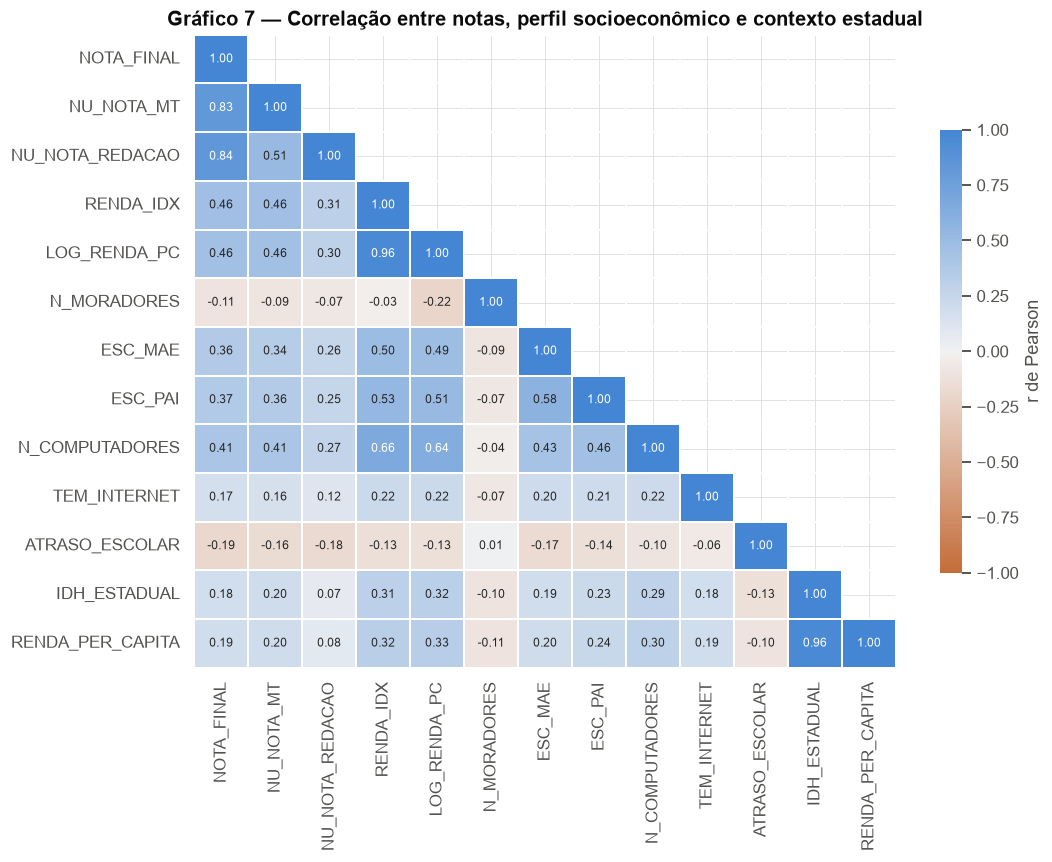

,r com NOTA_FINAL
RENDA_IDX,0.461
LOG_RENDA_PC,0.461
N_COMPUTADORES,0.411
ESC_PAI,0.374
ESC_MAE,0.362
RENDA_PER_CAPITA,0.193
IDH_ESTADUAL,0.184
TEM_INTERNET,0.172
N_MORADORES,-0.109
ATRASO_ESCOLAR,-0.191


In [8]:
cols_corr = ["NOTA_FINAL", "NU_NOTA_MT", "NU_NOTA_REDACAO", "RENDA_IDX"] + novas + ["IDH_ESTADUAL", "RENDA_PER_CAPITA"]
cols_corr = [c for c in dict.fromkeys(cols_corr) if c in df_modelo and c != "RENDA_PC_SM"]
corr = df_modelo[cols_corr].astype(float).corr()

# ---------- Gráfico 7 — heatmap de correlação ----------
mascara = np.triu(np.ones_like(corr, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=mascara, cmap=CMAP_DIVERGENTE, vmin=-1, vmax=1, center=0, annot=True, fmt=".2f",
            annot_kws={"size": 8}, linewidths=1, linecolor="white", cbar_kws={"shrink": 0.7, "label": "r de Pearson"},
            ax=ax)
ax.set_title("Gráfico 7 — Correlação entre notas, perfil socioeconômico e contexto estadual")
plt.tight_layout(); plt.show()

corr_nota = corr["NOTA_FINAL"].drop(["NOTA_FINAL", "NU_NOTA_MT", "NU_NOTA_REDACAO"]).sort_values(ascending=False)
display(corr_nota.to_frame("r com NOTA_FINAL"))

## 7. Preparação para a modelagem
*Conceito 2 (normalização) + base do Conceito 7*

**Features usadas:** variáveis do aluno (renda per capita, escolaridade dos pais, computadores, internet, moradores, atraso escolar, tipo de escola, faixa de renda, sexo, cor/raça) e do contexto (região e IDHM da UF).
- **Ficam de fora:** as notas das provas, porque são a própria composição do alvo (seria vazamento), e a renda per capita da UF (quase colinear com o IDHM entre as 27 UFs, como mostra a célula abaixo; manter as duas tornaria os coeficientes instáveis).

**`Pipeline` + `ColumnTransformer`** (`montar_preprocessador()` em `src/modelagem.py`):
- *Numéricas:* `SimpleImputer(median)` → `StandardScaler`.
- *Categóricas:* `SimpleImputer(most_frequent)` → `OneHotEncoder` (`TP_ESCOLA`, `REGIAO`, `FAIXA_RENDA`, `SEXO`, `COR_RACA`), removendo uma **categoria de referência** por variável: Pública, Nordeste, Baixa Renda, Feminino e Branca.

**Por que o `StandardScaler` é obrigatório no KNN?** O KNN classifica pela **distância euclidiana** entre alunos. Sem padronização, a variável de maior escala domina a distância: `N_MORADORES` varia de 1 a 20, enquanto `TEM_INTERNET` vai de 0 a 1 e o IDHM oscila só entre 0,74 e 0,87. Na prática, o "vizinho mais próximo" seria quem tem o mesmo número de moradores, e o IDHM quase não pesaria. Com todas as variáveis em média 0 e desvio 1, cada uma contribui de forma comparável. Na regressão, a padronização também permite comparar os coeficientes entre si (efeito de +1 desvio padrão).

**Sem vazamento de dados:**
1. A divisão **80/20** acontece **antes** de qualquer transformação que aprenda com os dados (`stratify` pelo alvo, `random_state = 42`).
2. Imputação, padronização e One-Hot ficam **dentro do Pipeline**: em cada dobra da validação cruzada, são ajustados só na parte de treino.
3. O undersampling do KNN (Seção 9) também fica no Pipeline, então só é aplicado aos dados de treino.

In [9]:
NUM_CANDIDATAS = ["LOG_RENDA_PC", "N_MORADORES", "ESC_MAE", "ESC_PAI", "N_COMPUTADORES", "TEM_INTERNET",
                  "ATRASO_ESCOLAR", "IDH_ESTADUAL"]
CAT_CANDIDATAS = ["TP_ESCOLA", "REGIAO", "FAIXA_RENDA", "SEXO", "COR_RACA"]
REFERENCIAS = {"TP_ESCOLA": "Pública", "REGIAO": "Nordeste", "FAIXA_RENDA": "Baixa Renda",
               "SEXO": "Feminino", "COR_RACA": "Branca"}

# Na simulação (fallback) parte das variáveis não existe; usamos as disponíveis
NUM = [c for c in NUM_CANDIDATAS if c in df_modelo]
CAT = [c for c in CAT_CANDIDATAS if c in df_modelo]

X = df_modelo[NUM + CAT]
y_reg = df_modelo["NOTA_FINAL"]
y_clf = df_modelo["ALTO_DESEMPENHO"]

# Uma única divisão para todos os modelos (estratificada pelo alvo da classificação)
X_train, X_test, yreg_train, yreg_test, y_train, y_test = train_test_split(
    X, y_reg, y_clf, test_size=0.20, stratify=y_clf, random_state=SEED)

print(f"Correlação IDHM × renda per capita entre as 27 UFs: r = {df_ibge['IDH_ESTADUAL'].corr(df_ibge['RENDA_PER_CAPITA']):.2f}")
print(f"Features: {len(NUM)} numéricas + {len(CAT)} categóricas")
print(f"Treino: {len(X_train):,} | Teste: {len(X_test):,}")
print(f"% alto desempenho, treino: {y_train.mean():.2%} | teste: {y_test.mean():.2%}")
print(f"Ausentes nas features do treino (imputados no Pipeline): {X_train.isna().sum()[lambda s: s > 0].to_dict()}")

Correlação IDHM × renda per capita entre as 27 UFs: r = 0.96
Features: 8 numéricas + 5 categóricas
Treino: 33,625 | Teste: 8,407
% alto desempenho, treino: 4.05% | teste: 4.06%
Ausentes nas features do treino (imputados no Pipeline): {'ESC_MAE': 1281, 'ESC_PAI': 3527}


## 8. Regressão Linear: prever a `NOTA_FINAL`
*Conceito 7a: Regressão Linear*

Métricas: **R²** (proporção da variância explicada), **MAE** (erro absoluto médio, em pontos) e **RMSE** (raiz do erro quadrático médio, que penaliza mais os erros grandes). Avaliadas no treino, no teste e por validação cruzada `KFold(5)` dentro do treino.

In [10]:
reg_lin = Pipeline([("prep", montar_preprocessador(NUM, CAT, REFERENCIAS)), ("modelo", LinearRegression())])
reg_lin.fit(X_train, yreg_train)

cv_reg = cross_validate(reg_lin, X_train, yreg_train, cv=KFold(5, shuffle=True, random_state=SEED),
                        scoring={"r2": "r2", "mae": "neg_mean_absolute_error", "rmse": "neg_root_mean_squared_error"})
metr_reg = pd.DataFrame({
    "Treino": metricas_regressao(yreg_train, reg_lin.predict(X_train)),
    "Teste": metricas_regressao(yreg_test, reg_lin.predict(X_test)),
    "CV média": {"R²": cv_reg["test_r2"].mean(), "MAE": -cv_reg["test_mae"].mean(), "RMSE": -cv_reg["test_rmse"].mean()},
    "CV desvio": {"R²": cv_reg["test_r2"].std(), "MAE": cv_reg["test_mae"].std(), "RMSE": cv_reg["test_rmse"].std()},
})
display(metr_reg.style.format("{:.3f}"))

,Treino,Teste,CV média,CV desvio
R²,0.310,0.299,0.309,0.006
MAE,63.172,62.715,63.211,0.700
RMSE,79.782,79.561,79.835,0.760


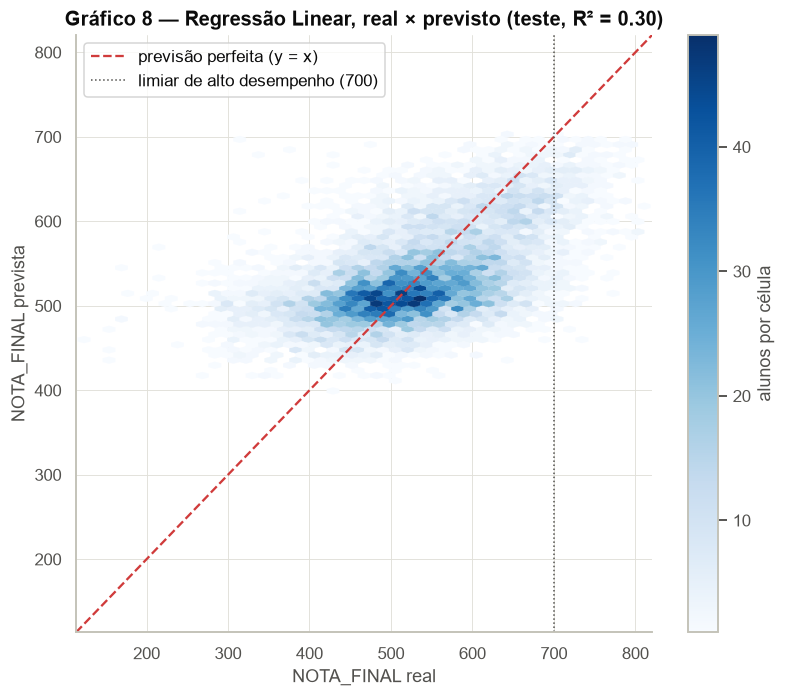

In [11]:
# ---------- Gráfico 8 — real × previsto (conjunto de teste) ----------
prev_teste = reg_lin.predict(X_test)
fig, ax = plt.subplots(figsize=(7.5, 6.5))
hb = ax.hexbin(yreg_test, prev_teste, gridsize=45, cmap="Blues", mincnt=1, linewidths=0.2)
lim = (min(yreg_test.min(), prev_teste.min()) - 10, max(yreg_test.max(), prev_teste.max()) + 10)
ax.plot(lim, lim, color=DESTAQUE, lw=1.5, ls="--", label="previsão perfeita (y = x)")
ax.axvline(LIMIAR_ALTO_DESEMPENHO, color=TINTA_SECUNDARIA, lw=1, ls=":", label=f"limiar de alto desempenho ({LIMIAR_ALTO_DESEMPENHO})")
r2_teste = metr_reg.loc["R²", "Teste"]
ax.set(xlim=lim, ylim=lim, xlabel="NOTA_FINAL real", ylabel="NOTA_FINAL prevista",
       title=f"Gráfico 8 — Regressão Linear, real × previsto (teste, R² = {r2_teste:.2f})")
fig.colorbar(hb, ax=ax, label="alunos por célula")
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

### 8.1 Interpretação dos coeficientes
As variáveis numéricas estão padronizadas, então o coeficiente indica **quantos pontos de `NOTA_FINAL` mudam quando a variável aumenta 1 desvio padrão**, mantidas as demais constantes. Nas categóricas, o coeficiente é a **diferença em pontos em relação à categoria de referência** (Pública, Nordeste, Baixa Renda, Feminino, Branca).

*Cuidado:* `LOG_RENDA_PC` e as dummies de `FAIXA_RENDA` vêm do mesmo `Q006` e são correlacionadas (Gráfico 7). O efeito total da renda fica **repartido** entre elas: as dummies medem só o desvio de cada faixa em relação à tendência da renda per capita. Por isso não convém ler os coeficientes de renda isoladamente, nem esperar que Média < Alta.

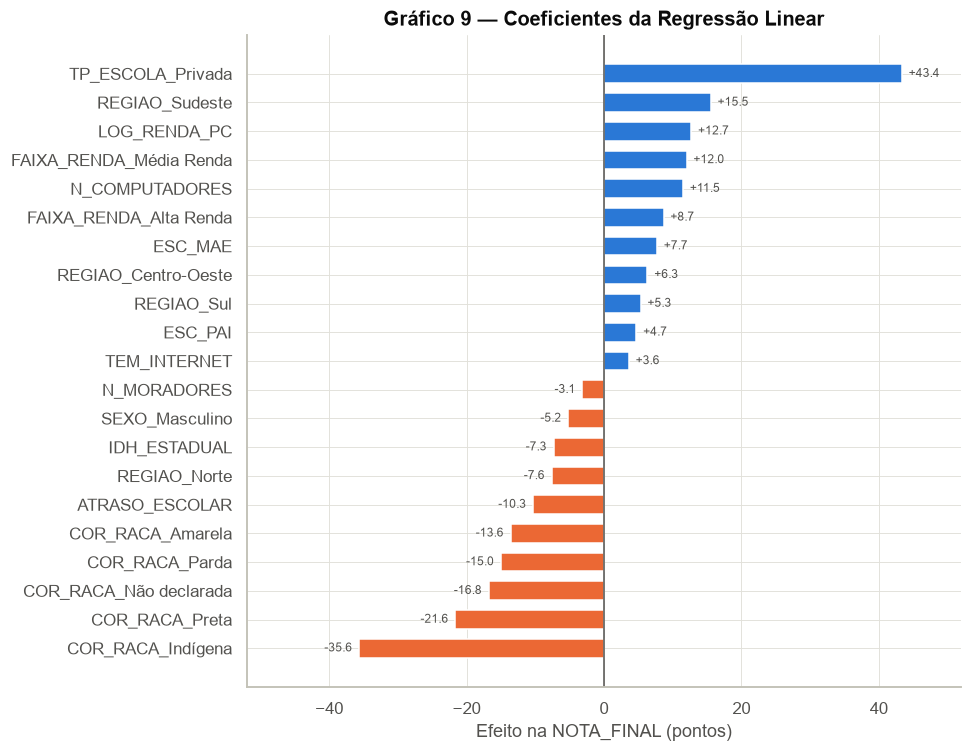

**Leitura dos coeficientes (gerada a partir do modelo ajustado):**
- Intercepto: 528.4 pontos (aluno de referência com as numéricas na média).
- Maiores efeitos positivos: `TP_ESCOLA_Privada` +43.4; `REGIAO_Sudeste` +15.5; `LOG_RENDA_PC` +12.7.
- Maiores efeitos negativos: `COR_RACA_Indígena` -35.6; `COR_RACA_Preta` -21.6; `COR_RACA_Não declarada` -16.8.
- Escola privada: a diferença **bruta** de médias é de 100.9 pontos (KPI 8). Mantidas as demais variáveis, o modelo atribui +43.4 pontos à escola privada. O restante da diferença bruta é explicado por renda, escolaridade dos pais e acesso a recursos, que já distinguem os dois grupos.
- IDHM da UF: -7.3 pontos por desvio padrão. O coeficiente é **condicional** à região e ao perfil do aluno. Isoladamente, a correlação estadual IDHM × nota média é r = 0.71 (KPI 11). Os dois números não se contradizem: a associação estadual não se repete no nível do aluno quando perfil e região são controlados (ver Limitações).

In [12]:
coefs = tabela_coeficientes(reg_lin).sort_values()

# ---------- Gráfico 9 — coeficientes da regressão linear ----------
fig, ax = plt.subplots(figsize=(9, 7))
cores = [AZUL if v > 0 else LARANJA for v in coefs.values]
ax.barh(coefs.index, coefs.values, color=cores, height=0.65)
ax.axvline(0, color=TINTA_SECUNDARIA, lw=1)
for i, v in enumerate(coefs.values):
    ax.text(v + (1 if v >= 0 else -1), i, f"{v:+.1f}", va="center", ha="left" if v >= 0 else "right", fontsize=8,
            color=TINTA_SECUNDARIA)
margem = coefs.abs().max() * 1.2
ax.set(xlim=(-margem, margem), xlabel="Efeito na NOTA_FINAL (pontos)", ylabel="",
       title="Gráfico 9 — Coeficientes da Regressão Linear")
plt.tight_layout(); plt.show()

positivos = coefs[coefs > 0].sort_values(ascending=False).head(3)
negativos = coefs[coefs < 0].sort_values().head(3)
texto = ["**Leitura dos coeficientes (gerada a partir do modelo ajustado):**",
         f"- Intercepto: {reg_lin.named_steps['modelo'].intercept_:.1f} pontos (aluno de referência com as numéricas na média).",
         "- Maiores efeitos positivos: " + "; ".join(f"`{k}` {v:+.1f}" for k, v in positivos.items()) + ".",
         "- Maiores efeitos negativos: " + "; ".join(f"`{k}` {v:+.1f}" for k, v in negativos.items()) + "."]
if "TP_ESCOLA_Privada" in coefs:
    bruto = aux["med_escola"]["Privada"] - aux["med_escola"]["Pública"]
    texto.append(f"- Escola privada: a diferença **bruta** de médias é de {bruto:.1f} pontos (KPI 8). Mantidas as demais variáveis, "
                 f"o modelo atribui {coefs['TP_ESCOLA_Privada']:+.1f} pontos à escola privada. O restante da diferença bruta é "
                 "explicado por renda, escolaridade dos pais e acesso a recursos, que já distinguem os dois grupos.")
if "IDH_ESTADUAL" in coefs:
    texto.append(f"- IDHM da UF: {coefs['IDH_ESTADUAL']:+.1f} pontos por desvio padrão. O coeficiente é **condicional** à região e ao perfil do aluno. "
                 f"Isoladamente, a correlação estadual IDHM × nota média é r = {aux['corr_idh']:.2f} (KPI 11). Os dois números não se contradizem: "
                 "a associação estadual não se repete no nível do aluno quando perfil e região são controlados (ver Limitações).")
display(Markdown("\n".join(texto)))

## 9. Classificação: alunos com `NOTA_FINAL > 700`
*Conceitos 7a (Regressão Logística) e 7b (Árvore de Decisão e KNN)*

**Desbalanceamento:** só cerca de 4% dos alunos passam de 700 pontos (Seção 6). Um modelo que dissesse "não" para todos teria ~96% de acurácia e seria inútil. Por isso:
- a métrica de seleção é o **F1 da classe positiva**, e não a acurácia;
- o **grau de rebalanceamento entra como hiperparâmetro**, escolhido pela validação cruzada:
  - Regressão Logística e Árvore: `class_weight` (peso 1 para a classe 0 e peso 3, 6 ou 10 para a classe 1, ou `"balanced"`, que aqui dá à classe 1 um peso ~24 vezes maior, a razão entre as classes);
  - KNN, que não aceita pesos por classe: `RandomUnderSampler` (`imbalanced-learn`) **dentro do Pipeline**, com proporção minoritária/majoritária de 0,1, 0,2, 0,5 ou 1,0. Assim o undersampling só é aplicado no treino de cada dobra.

**Ajuste de hiperparâmetros:** `GridSearchCV` com `StratifiedKFold(5, shuffle=True, random_state=42)`, `refit="f1"`. Também registramos precisão, recall, acurácia e ROC-AUC de cada dobra.

In [13]:
cv_estrat = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
METRICAS_CV = {"F1": "f1", "Precisão": "precision", "Recall": "recall", "Acurácia": "accuracy", "ROC-AUC": "roc_auc"}
PESOS = [{0: 1, 1: 3}, {0: 1, 1: 6}, {0: 1, 1: 10}, "balanced"]

modelos = {
    "Regressão Logística": (
        Pipeline([("prep", montar_preprocessador(NUM, CAT, REFERENCIAS)),
                  ("modelo", LogisticRegression(max_iter=2000, random_state=SEED))]),
        {"modelo__C": [0.01, 0.1, 1, 10], "modelo__class_weight": [None] + PESOS}),
    "Árvore de Decisão": (
        Pipeline([("prep", montar_preprocessador(NUM, CAT, REFERENCIAS)),
                  ("modelo", DecisionTreeClassifier(random_state=SEED))]),
        {"modelo__max_depth": [3, 5, 7, 10, None], "modelo__min_samples_leaf": [1, 50, 200],
         "modelo__class_weight": PESOS}),
    "KNN": (
        ImbPipeline([("prep", montar_preprocessador(NUM, CAT, REFERENCIAS)),
                     ("under", RandomUnderSampler(random_state=SEED)),
                     ("modelo", KNeighborsClassifier())]),
        {"modelo__n_neighbors": [51, 101, 201, 301, 401], "modelo__weights": ["uniform", "distance"],
         "under__sampling_strategy": [0.1, 0.2, 0.5, 1.0]}),
}

buscas = {}
for nome, (pipeline, grade) in modelos.items():
    busca = GridSearchCV(pipeline, grade, scoring=METRICAS_CV, refit="F1", cv=cv_estrat, n_jobs=-1)
    busca.fit(X_train, y_train)
    buscas[nome] = busca
    n_comb = len(busca.cv_results_["params"])
    print(f"{nome:<20} {n_comb:>3} combinações × 5 dobras | melhor: {formatar_parametros(busca.best_params_)}")

Regressão Logística   20 combinações × 5 dobras | melhor: C=0.01, class_weight={0: 1, 1: 6}


Árvore de Decisão     60 combinações × 5 dobras | melhor: class_weight={0: 1, 1: 6}, max_depth=5, min_samples_leaf=50


KNN                   40 combinações × 5 dobras | melhor: n_neighbors=201, weights=uniform, sampling_strategy=0.2


## 10. Avaliação dos modelos
*Métricas de avaliação: precisão, recall, F1, matriz de confusão, validação cruzada e overfitting*

- **Precisão:** dos alunos que o modelo apontou como "> 700", quantos realmente são.
- **Recall:** dos alunos que realmente passaram de 700, quantos o modelo encontrou.
- **F1:** média harmônica de precisão e recall.
- **ROC-AUC:** capacidade de ordenar os alunos por probabilidade, independentemente do limiar.
- **Overfitting:** comparamos o F1 no **treino** com o F1 no **teste** e na **validação cruzada**. Uma diferença grande indica que o modelo decorou o treino.

In [14]:
linhas = []
for nome, busca in buscas.items():
    modelo = busca.best_estimator_
    treino = metricas_classificacao(modelo, X_train, y_train)
    teste = metricas_classificacao(modelo, X_test, y_test)
    cv = resumo_cv(busca, {"F1": "F1", "Precisão": "Precisão", "Recall": "Recall", "ROC-AUC": "ROC-AUC"})
    linhas.append({
        "Modelo": nome, "Hiperparâmetros": formatar_parametros(busca.best_params_),
        "CV F1": f"{cv['CV F1 (média)']:.3f} ± {cv['CV F1 (dp)']:.3f}",
        "CV ROC-AUC": f"{cv['CV ROC-AUC (média)']:.3f} ± {cv['CV ROC-AUC (dp)']:.3f}",
        "F1 treino": treino["F1"], **{f"{k} teste": v for k, v in teste.items()},
        "Gap F1 (treino − teste)": treino["F1"] - teste["F1"],
        "_cv_f1": cv["CV F1 (média)"], "_cv_f1_dp": cv["CV F1 (dp)"], "_treino": treino, "_teste": teste,
    })
comparativo = pd.DataFrame(linhas).set_index("Modelo")
colunas_visiveis = [c for c in comparativo.columns if not c.startswith("_")]
display(comparativo[colunas_visiveis].style.format(precision=3))
print(f"Referência (taxa base da classe positiva no teste): precisão de um palpite aleatório = {taxa_base(y_test):.3f}")

,Hiperparâmetros,CV F1,CV ROC-AUC,F1 treino,Acurácia teste,Precisão teste,Recall teste,F1 teste,ROC-AUC teste,Gap F1 (treino − teste)
Modelo,,,,,,,,,,
Regressão Logística,"C=0.01, class_weight={0: 1, 1: 6}",0.344 ± 0.019,0.892 ± 0.017,0.349,0.920,0.253,0.499,0.336,0.872,0.014
Árvore de Decisão,"class_weight={0: 1, 1: 6}, max_depth=5, min_samples_leaf=50",0.339 ± 0.021,0.881 ± 0.015,0.350,0.909,0.229,0.525,0.319,0.862,0.030
KNN,"n_neighbors=201, weights=uniform, sampling_strategy=0.2",0.350 ± 0.019,0.887 ± 0.016,0.348,0.929,0.272,0.440,0.336,0.864,0.012


Referência (taxa base da classe positiva no teste): precisão de um palpite aleatório = 0.041


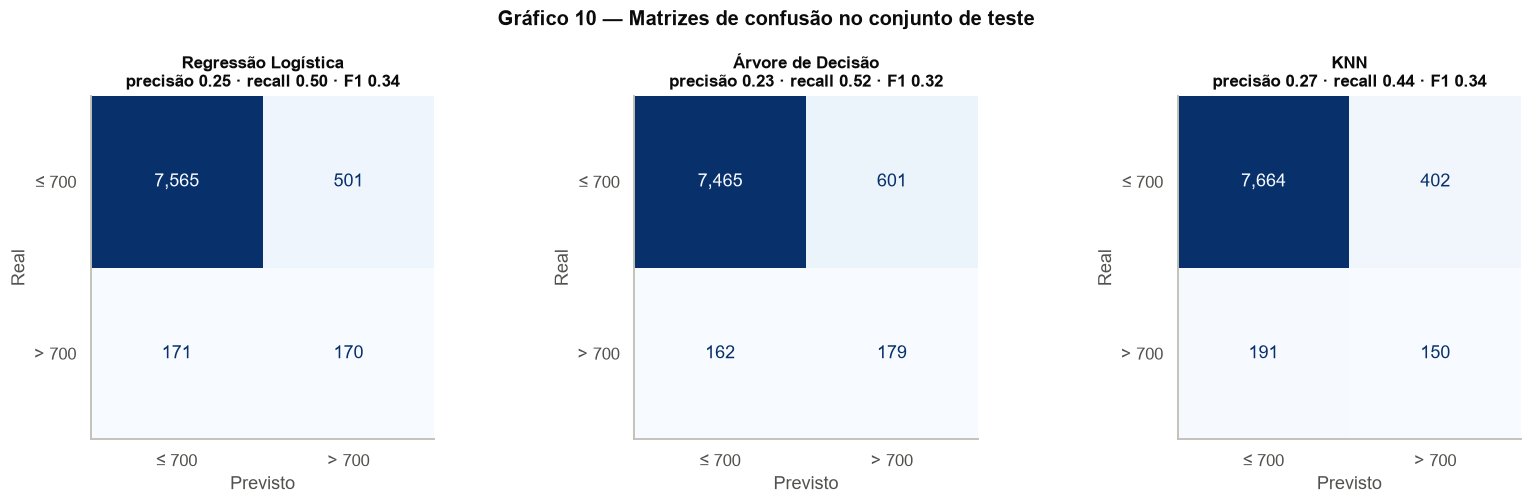

In [15]:
# ---------- Gráfico 10 — matrizes de confusão (teste) ----------
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, (nome, busca) in zip(axes, buscas.items()):
    ConfusionMatrixDisplay.from_estimator(busca.best_estimator_, X_test, y_test, ax=ax, cmap="Blues",
                                          colorbar=False, display_labels=["≤ 700", "> 700"], values_format=",")
    t = comparativo.loc[nome, "_teste"]
    ax.set_title(f"{nome}\nprecisão {t['Precisão']:.2f} · recall {t['Recall']:.2f} · F1 {t['F1']:.2f}", fontsize=11)
    ax.set(xlabel="Previsto", ylabel="Real")
    ax.grid(False)
fig.suptitle("Gráfico 10 — Matrizes de confusão no conjunto de teste", fontweight="bold", fontsize=13)
plt.tight_layout(); plt.show()

### 10.1 Overfitting: profundidade da árvore
A árvore é o modelo mais sujeito a overfitting. Variamos só a `max_depth` (mantendo o `class_weight` escolhido e `min_samples_leaf = 1`, sem nenhuma outra restrição) e comparamos o F1 no treino com o F1 da validação cruzada.

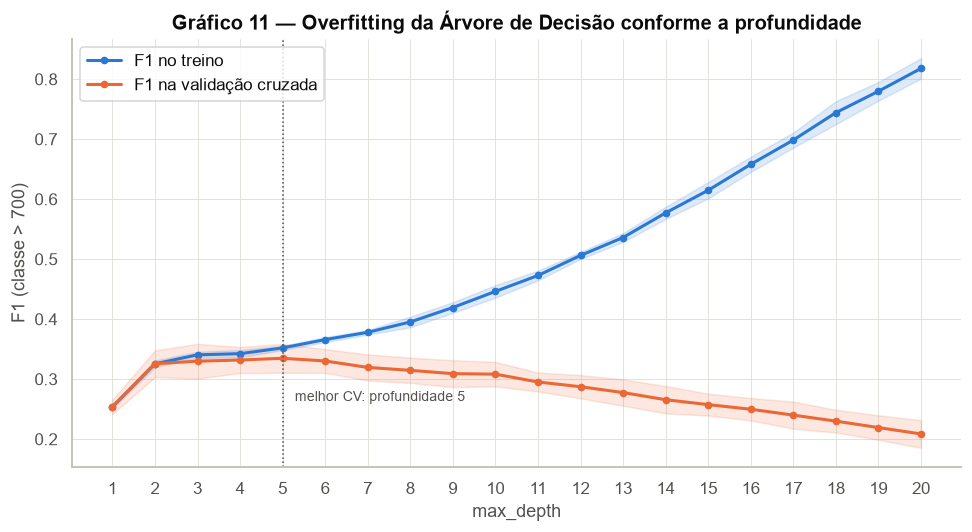

Com profundidade 5, o F1 de validação atinge o máximo (0.335). Na profundidade 20, o F1 de treino é 0.818 e o de validação, 0.209 (0.126 abaixo do máximo). A diferença treino − validação de 0.609 é o padrão típico de **overfitting**: a árvore passa a decorar combinações raras do treino, e o desempenho fora dele piora. Por isso o GridSearchCV limita a profundidade e o tamanho mínimo das folhas.

In [16]:
params_arvore = buscas["Árvore de Decisão"].best_params_
arvore_curva = Pipeline([("prep", montar_preprocessador(NUM, CAT, REFERENCIAS)),
                         ("modelo", DecisionTreeClassifier(random_state=SEED, min_samples_leaf=1,
                                                           class_weight=params_arvore["modelo__class_weight"]))])
profundidades = np.arange(1, 21)
f1_treino, f1_val = validation_curve(arvore_curva, X_train, y_train, param_name="modelo__max_depth",
                                     param_range=profundidades, cv=cv_estrat, scoring="f1", n_jobs=-1)

# ---------- Gráfico 11 — curva de validação (treino × validação cruzada) ----------
fig, ax = plt.subplots(figsize=(9, 5))
for valores, cor, rotulo in [(f1_treino, AZUL, "F1 no treino"), (f1_val, LARANJA, "F1 na validação cruzada")]:
    media, dp = valores.mean(axis=1), valores.std(axis=1)
    ax.plot(profundidades, media, color=cor, lw=2, marker="o", markersize=4, label=rotulo)
    ax.fill_between(profundidades, media - dp, media + dp, color=cor, alpha=0.15)
melhor_prof = int(profundidades[f1_val.mean(axis=1).argmax()])
ax.axvline(melhor_prof, color=TINTA_SECUNDARIA, ls=":", lw=1)
ax.annotate(f"melhor CV: profundidade {melhor_prof}", (melhor_prof, f1_val.mean(axis=1).max()),
            xytext=(8, -28), textcoords="offset points", fontsize=9, color=TINTA_SECUNDARIA)
ax.set(xlabel="max_depth", ylabel="F1 (classe > 700)", xticks=profundidades,
       title="Gráfico 11 — Overfitting da Árvore de Decisão conforme a profundidade")
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

gap_prof20 = f1_treino[-1].mean() - f1_val[-1].mean()
queda_val = f1_val.mean(axis=1).max() - f1_val[-1].mean()
diagnostico = ("o padrão típico de **overfitting**: a árvore passa a decorar combinações raras do treino, e o desempenho fora dele piora. "
               "Por isso o GridSearchCV limita a profundidade e o tamanho mínimo das folhas."
               if gap_prof20 > 0.05 and queda_val > 0 else
               "uma diferença pequena, sem overfitting claro nessa faixa de profundidades.")
display(Markdown(
    f"Com profundidade {melhor_prof}, o F1 de validação atinge o máximo ({f1_val.mean(axis=1).max():.3f}). "
    f"Na profundidade 20, o F1 de treino é {f1_treino[-1].mean():.3f} e o de validação, {f1_val[-1].mean():.3f} "
    f"({queda_val:.3f} abaixo do máximo). A diferença treino − validação de {gap_prof20:.3f} é {diagnostico}"))

### 10.2 A árvore escolhida
Como leitura do Gráfico 12 — as variáveis numéricas passaram pelo `StandardScaler`, então os limiares estão em **desvios padrão** (um limiar como `ESC_PAI <= 0.5` significaria escolaridade do pai até meio desvio padrão acima da média). As dummies valem 0 ou 1 (`TP_ESCOLA_Privada <= 0.5` = escola pública). Em `value`, as proporções já são **ponderadas pelo `class_weight`**, por isso a classe "> 700" aparece maior do que os ~4% reais.

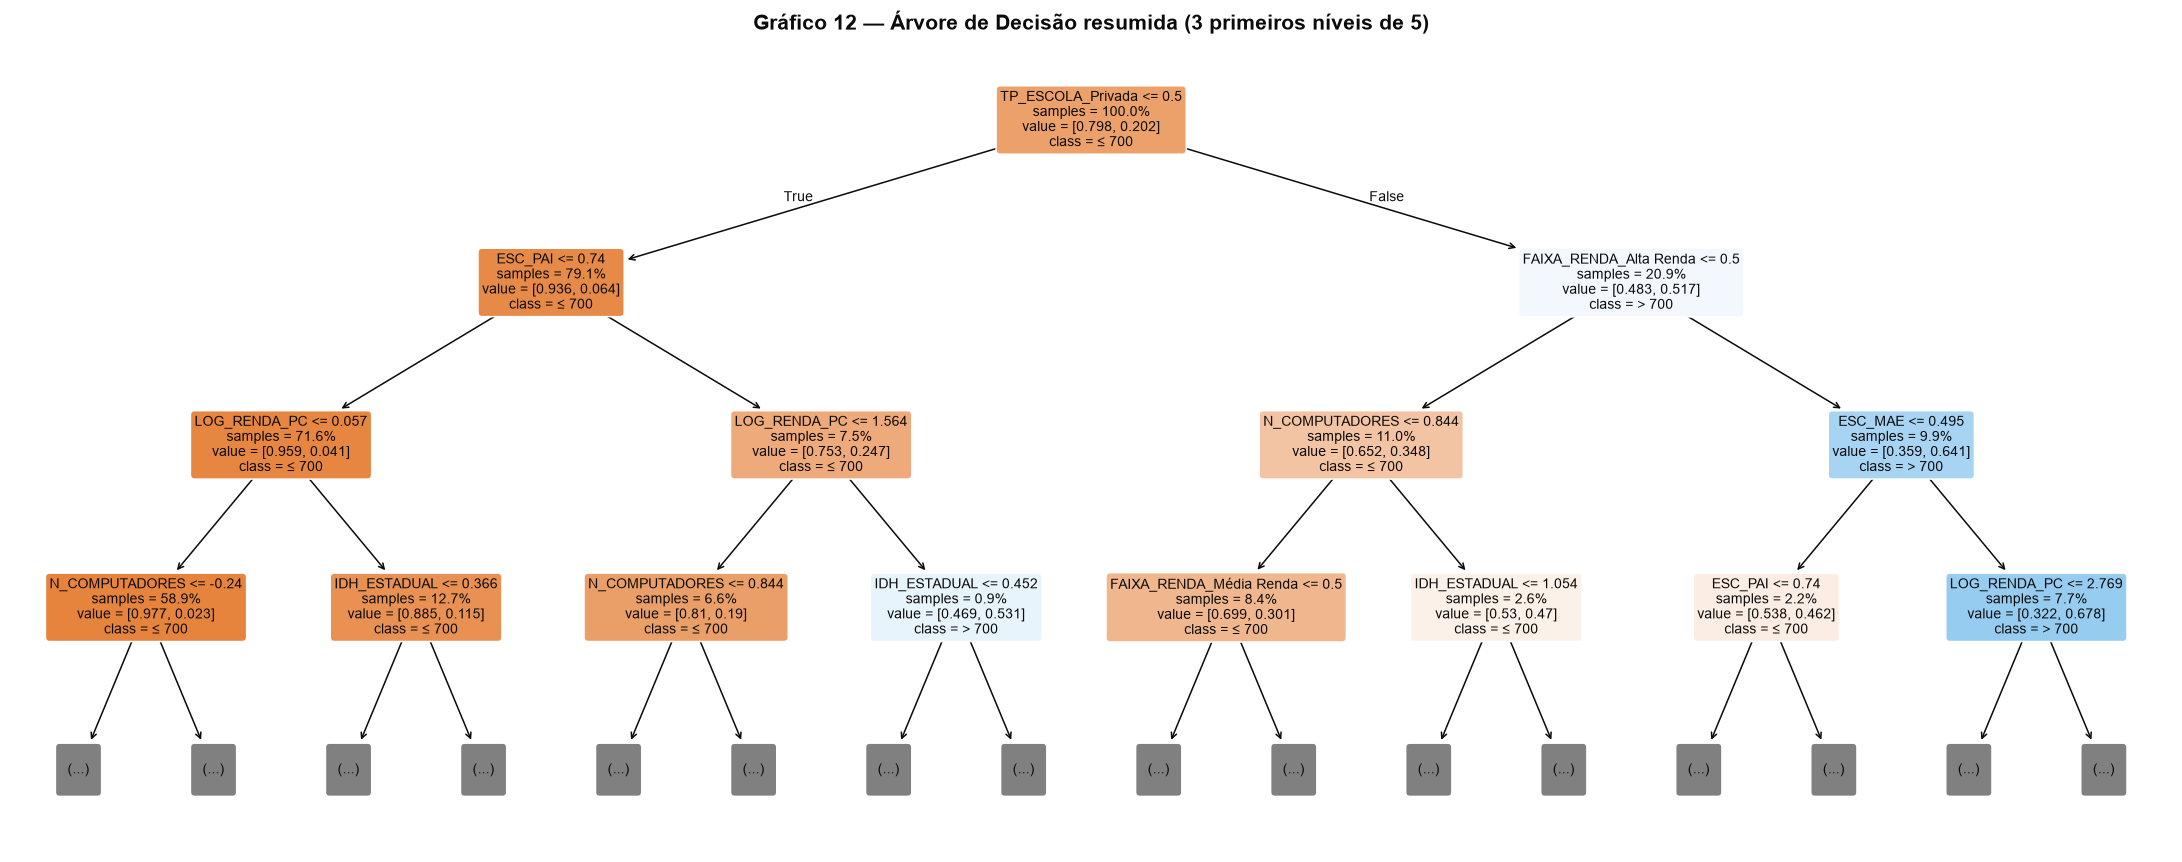

In [17]:
# ---------- Gráfico 12 — árvore de decisão resumida (3 primeiros níveis) ----------
arvore = buscas["Árvore de Decisão"].best_estimator_
nomes_features = arvore.named_steps["prep"].get_feature_names_out()
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(arvore.named_steps["modelo"], max_depth=3, feature_names=nomes_features, class_names=["≤ 700", "> 700"],
          filled=True, impurity=False, proportion=True, rounded=True, fontsize=9, ax=ax)
ax.set_title(f"Gráfico 12 — Árvore de Decisão resumida (3 primeiros níveis de {arvore.named_steps['modelo'].get_depth()})",
             fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

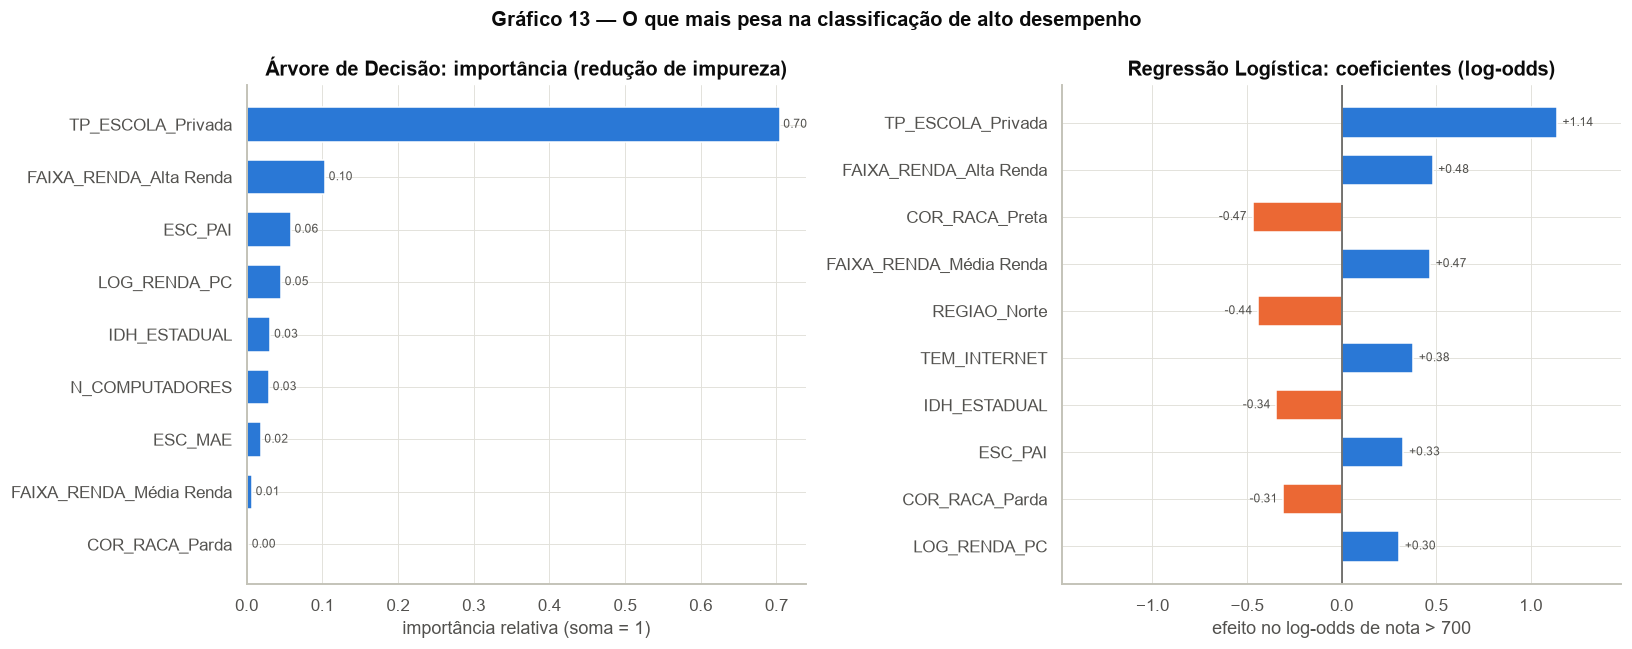

In [18]:
# ---------- Gráfico 13 — importância das variáveis ----------
importancia_arvore = pd.Series(arvore.named_steps["modelo"].feature_importances_, index=nomes_features)
importancia_arvore = importancia_arvore[importancia_arvore > 0].sort_values().tail(10)
coef_log = tabela_coeficientes(buscas["Regressão Logística"].best_estimator_)
coef_log_top = coef_log.reindex(coef_log.abs().sort_values().tail(10).index)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
ax1.barh(importancia_arvore.index, importancia_arvore.values, color=AZUL, height=0.65)
for i, v in enumerate(importancia_arvore.values):
    ax1.text(v + 0.005, i, f"{v:.2f}", va="center", fontsize=8, color=TINTA_SECUNDARIA)
ax1.set(title="Árvore de Decisão: importância (redução de impureza)", xlabel="importância relativa (soma = 1)")

ax2.barh(coef_log_top.index, coef_log_top.values, color=[AZUL if v > 0 else LARANJA for v in coef_log_top.values], height=0.65)
ax2.axvline(0, color=TINTA_SECUNDARIA, lw=1)
for i, v in enumerate(coef_log_top.values):
    ax2.text(v + (0.03 if v >= 0 else -0.03), i, f"{v:+.2f}", va="center", ha="left" if v >= 0 else "right",
             fontsize=8, color=TINTA_SECUNDARIA)
m = coef_log_top.abs().max() * 1.3
ax2.set(xlim=(-m, m), title="Regressão Logística: coeficientes (log-odds)", xlabel="efeito no log-odds de nota > 700")
fig.suptitle("Gráfico 13 — O que mais pesa na classificação de alto desempenho", fontweight="bold", fontsize=13)
plt.tight_layout(); plt.show()

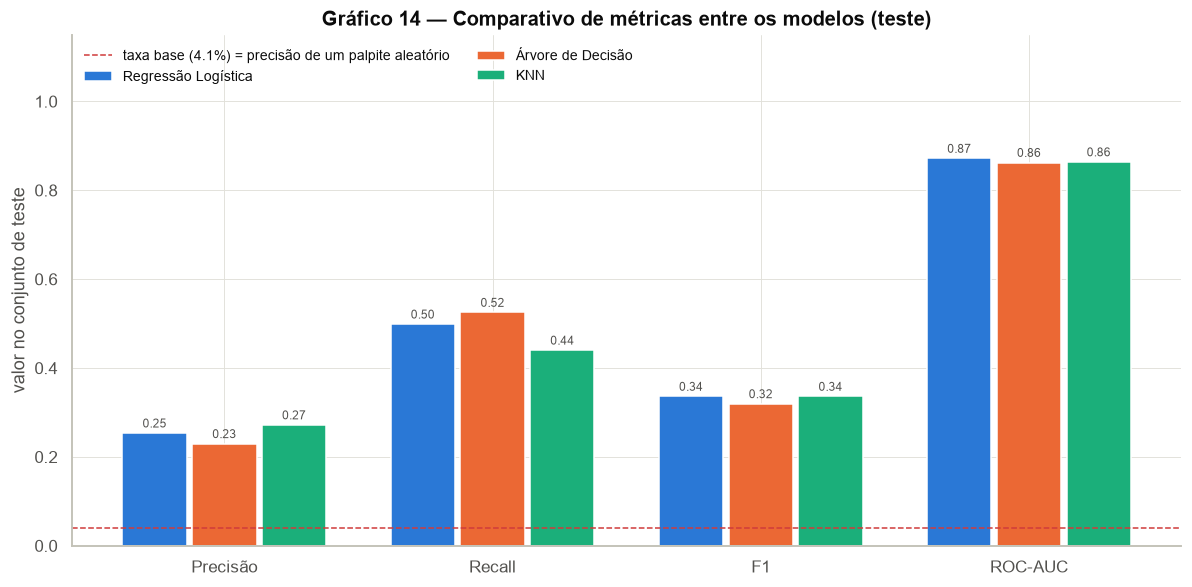

In [19]:
# ---------- Gráfico 14 — comparativo de métricas no teste ----------
metricas_plot = ["Precisão", "Recall", "F1", "ROC-AUC"]
dados_plot = pd.DataFrame({nome: comparativo.loc[nome, "_teste"] for nome in buscas}).loc[metricas_plot]

fig, ax = plt.subplots(figsize=(11, 5.5))
largura = 0.26
x = np.arange(len(metricas_plot))
for j, nome in enumerate(dados_plot.columns):
    barras = ax.bar(x + (j - 1) * largura, dados_plot[nome], width=largura - 0.02, color=CORES_MODELOS[nome], label=nome)
    ax.bar_label(barras, fmt="%.2f", fontsize=8, padding=2, color=TINTA_SECUNDARIA)
ax.axhline(taxa_base(y_test), color=DESTAQUE, ls="--", lw=1,
           label=f"taxa base ({taxa_base(y_test):.1%}) = precisão de um palpite aleatório")
ax.set(xticks=x, xticklabels=metricas_plot, ylim=(0, 1.15), ylabel="valor no conjunto de teste",
       title="Gráfico 14 — Comparativo de métricas entre os modelos (teste)")
ax.legend(loc="upper left", ncols=2, frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

### 10.3 Tabela comparativa final

In [20]:
tabela_final = pd.DataFrame({
    "CV F1 (média ± dp)": comparativo["CV F1"],
    "Acurácia": comparativo["Acurácia teste"],
    "Precisão": comparativo["Precisão teste"],
    "Recall": comparativo["Recall teste"],
    "F1": comparativo["F1 teste"],
    "ROC-AUC": comparativo["ROC-AUC teste"],
    "F1 treino": comparativo["F1 treino"],
    "Gap F1 treino − teste": comparativo["Gap F1 (treino − teste)"],
})
display(tabela_final.style.format(precision=3).highlight_max(subset=["F1", "ROC-AUC"], color="#cde2fb"))

melhor_f1 = tabela_final["F1"].idxmax()
melhor_auc = tabela_final["ROC-AUC"].idxmax()

# Seleção do modelo final pela VALIDAÇÃO CRUZADA (o teste só informa o desempenho final).
# Se a diferença de F1 entre o melhor e o pior modelo na CV for menor que o maior desvio padrão da CV,
# os modelos estão em empate técnico e escolhemos o mais interpretável (Regressão Logística).
cv_f1 = comparativo["_cv_f1"]
amplitude_cv = cv_f1.max() - cv_f1.min()
empate_tecnico = amplitude_cv < comparativo["_cv_f1_dp"].max()
modelo_final = "Regressão Logística" if empate_tecnico else cv_f1.idxmax()
maior_gap = tabela_final["Gap F1 treino − teste"].idxmax()
gap_max = tabela_final.loc[maior_gap, "Gap F1 treino − teste"]
# Teste dentro de 2 desvios da média da CV = desempenho de teste compatível com a variação entre dobras
dentro_cv = {n: abs(comparativo.loc[n, "F1 teste"] - comparativo.loc[n, "_cv_f1"]) <= 2 * comparativo.loc[n, "_cv_f1_dp"]
             for n in comparativo.index}
if gap_max < 0.05 and all(dentro_cv.values()):
    conclusao = ("todos os gaps ficam abaixo de 0,05 e o F1 de teste de cada modelo está a até 2 desvios da média da CV: "
                 "depois do ajuste de hiperparâmetros, **não há overfitting relevante**.")
else:
    fora = [n for n, ok in dentro_cv.items() if not ok]
    conclusao = (f"há sinal de overfitting: gap máximo de {gap_max:.3f}"
                 + (f"; F1 de teste fora de 2 desvios da CV em: {', '.join(fora)}" if fora else "") + ".")
display(Markdown(
    f"- **Seleção pela validação cruzada:** maior CV F1 = **{cv_f1.idxmax()}** ({cv_f1.max():.3f}). A diferença entre o melhor e o pior modelo "
    f"({amplitude_cv:.3f}) é {'menor' if empate_tecnico else 'maior'} que o maior desvio padrão da CV ({comparativo['_cv_f1_dp'].max():.3f}), "
    + ("o que configura **empate técnico**. Escolhemos a **Regressão Logística** por ser a mais interpretável (coeficientes com sinal e magnitude)."
       if empate_tecnico else f"então o modelo final é **{modelo_final}**.") + "\n"
    f"- Melhor F1 no teste: **{melhor_f1}** ({tabela_final.loc[melhor_f1, 'F1']:.3f}). "
    f"Melhor ROC-AUC: **{melhor_auc}** ({tabela_final.loc[melhor_auc, 'ROC-AUC']:.3f}).\n"
    f"- Maior gap de F1 entre treino e teste: **{maior_gap}** ({gap_max:.3f}). Conclusão: {conclusao}\n"
    f"- A acurácia (~{tabela_final['Acurácia'].mean():.0%}) é enganosa neste problema: classificar todos como \"≤ 700\" "
    f"daria {1 - taxa_base(y_test):.1%}."))

,CV F1 (média ± dp),Acurácia,Precisão,Recall,F1,ROC-AUC,F1 treino,Gap F1 treino − teste
Modelo,,,,,,,,
Regressão Logística,0.344 ± 0.019,0.920,0.253,0.499,0.336,0.872,0.349,0.014
Árvore de Decisão,0.339 ± 0.021,0.909,0.229,0.525,0.319,0.862,0.350,0.030
KNN,0.350 ± 0.019,0.929,0.272,0.440,0.336,0.864,0.348,0.012


- **Seleção pela validação cruzada:** maior CV F1 = **KNN** (0.350). A diferença entre o melhor e o pior modelo (0.011) é menor que o maior desvio padrão da CV (0.021), o que configura **empate técnico**. Escolhemos a **Regressão Logística** por ser a mais interpretável (coeficientes com sinal e magnitude).
- Melhor F1 no teste: **Regressão Logística** (0.336). Melhor ROC-AUC: **Regressão Logística** (0.872).
- Maior gap de F1 entre treino e teste: **Árvore de Decisão** (0.030). Conclusão: todos os gaps ficam abaixo de 0,05 e o F1 de teste de cada modelo está a até 2 desvios da média da CV: depois do ajuste de hiperparâmetros, **não há overfitting relevante**.
- A acurácia (~92%) é enganosa neste problema: classificar todos como "≤ 700" daria 95.9%.

## 11. Principais insights
*Conceito 5: Visualização e storytelling*

Os quatro insights abaixo são **gerados a partir das variáveis do notebook**: nenhum número foi digitado à mão.

In [21]:
k = df_kpis.set_index("#")["Valor"]
med_escola = aux["med_escola"]
abst = aux["abst_renda"]
nota_renda = df_pres.groupby("FAIXA_RENDA", observed=True)["NOTA_FINAL"].mean()
alto_escola = df_modelo.groupby("TP_ESCOLA")["ALTO_DESEMPENHO"].mean() * 100
tab_uf = aux["tab_uf"]
uf_max, uf_min = aux["media_uf"].idxmax(), aux["media_uf"].idxmin()
lin = metr_reg["Teste"]
best = tabela_final.loc[modelo_final]

insights = f"""
**1. A escola explica parte da diferença, mas não sozinha.** Alunos de escola privada têm nota final média de {med_escola['Privada']:.1f},
contra {med_escola['Pública']:.1f} na pública (razão {k[8]:.2f}, KPI 8). Passam de 700 pontos {alto_escola['Privada']:.1f}% dos alunos
da rede privada e {alto_escola['Pública']:.1f}% da pública. Na Regressão Linear, controlando renda, escolaridade dos pais e acesso a recursos,
a escola privada vale {coefs.get('TP_ESCOLA_Privada', float('nan')):+.1f} pontos, ou {coefs.get('TP_ESCOLA_Privada', float('nan')) / (med_escola['Privada'] - med_escola['Pública']):.0%} da diferença bruta de {med_escola['Privada'] - med_escola['Pública']:.1f}.

**2. A renda pesa duas vezes: em quem chega à prova e em quanto tira.** A abstenção é de {abst['Baixa Renda']:.1f}% na baixa renda
contra {abst['Alta Renda']:.1f}% na alta renda ({k[14]:.1f} p.p., KPI 14). Entre os que fazem a prova, a média sobe de {nota_renda['Baixa Renda']:.1f}
(baixa renda) para {nota_renda['Alta Renda']:.1f} (alta renda). Mesmo assim, {k[18]:.1f}% dos alunos de baixa renda passam de 600 pontos (KPI 18).

**3. O território importa, mas a correlação estadual é ecológica.** No nível das 27 UFs, IDHM e nota média têm r = {k[11]:.2f} (KPI 11),
e a média vai de {aux['media_uf'].min():.1f} ({uf_min}) a {aux['media_uf'].max():.1f} ({uf_max}). No modelo individual, porém, o IDHM
tem coeficiente de {coefs.get('IDH_ESTADUAL', float('nan')):+.1f} pontos por desvio padrão depois de controlar perfil e região. A associação estadual forte
não se repete no nível do aluno, porque a vantagem dos estados mais desenvolvidos passa pela composição socioeconômica de quem faz a prova
(e pela região, que já entra no modelo).

**4. O perfil socioeconômico capta a tendência, mas não prevê o aluno.** A Regressão Linear explica {lin['R²']:.1%} da variância da nota
(R² = {lin['R²']:.3f}; erro médio de {lin['MAE']:.1f} pontos). Os três classificadores ficam próximos (CV F1 entre {cv_f1.min():.3f} e {cv_f1.max():.3f}).
O modelo escolhido, {modelo_final}, tem no teste F1 = {best['F1']:.3f} e ROC-AUC = {best['ROC-AUC']:.3f}:
o modelo encontra {best['Recall']:.0%} dos alunos acima de 700, mas só {best['Precisão']:.0%} dos apontados realmente chegam lá
(taxa base: {taxa_base(y_test):.1%}). Origem social aumenta muito a chance de alto desempenho, mas não a determina.
"""
display(Markdown(insights))


**1. A escola explica parte da diferença, mas não sozinha.** Alunos de escola privada têm nota final média de 616.1,
contra 515.2 na pública (razão 1.20, KPI 8). Passam de 700 pontos 15.1% dos alunos
da rede privada e 1.2% da pública. Na Regressão Linear, controlando renda, escolaridade dos pais e acesso a recursos,
a escola privada vale +43.4 pontos, ou 43% da diferença bruta de 100.9.

**2. A renda pesa duas vezes: em quem chega à prova e em quanto tira.** A abstenção é de 29.6% na baixa renda
contra 9.9% na alta renda (19.8 p.p., KPI 14). Entre os que fazem a prova, a média sobe de 506.2
(baixa renda) para 620.5 (alta renda). Mesmo assim, 14.3% dos alunos de baixa renda passam de 600 pontos (KPI 18).

**3. O território importa, mas a correlação estadual é ecológica.** No nível das 27 UFs, IDHM e nota média têm r = 0.71 (KPI 11),
e a média vai de 494.4 (AM) a 561.2 (MG). No modelo individual, porém, o IDHM
tem coeficiente de -7.3 pontos por desvio padrão depois de controlar perfil e região. A associação estadual forte
não se repete no nível do aluno, porque a vantagem dos estados mais desenvolvidos passa pela composição socioeconômica de quem faz a prova
(e pela região, que já entra no modelo).

**4. O perfil socioeconômico capta a tendência, mas não prevê o aluno.** A Regressão Linear explica 29.9% da variância da nota
(R² = 0.299; erro médio de 62.7 pontos). Os três classificadores ficam próximos (CV F1 entre 0.339 e 0.350).
O modelo escolhido, Regressão Logística, tem no teste F1 = 0.336 e ROC-AUC = 0.872:
o modelo encontra 50% dos alunos acima de 700, mas só 25% dos apontados realmente chegam lá
(taxa base: 4.1%). Origem social aumenta muito a chance de alto desempenho, mas não a determina.


In [22]:
# Resultados salvos para o relatório, o README e docs/ (os textos citam exatamente estes valores)
def _f(v):
    return float(round(float(v), 4))

resultados = {
    "base": {"amostra": int(len(df)), "presentes_validos": int(len(df_pres)), "treino": int(len(X_train)),
             "teste": int(len(X_test)), "taxa_alto_desempenho": _f(y_clf.mean()),
             "features_num": NUM, "features_cat": CAT},
    "kpis": {int(i): {"kpi": n, "valor": _f(v), "obs": o}
             for i, n, v, o in df_kpis[["#", "KPI", "Valor", "Observação"]].itertuples(index=False)},
    "regressao_linear": {"teste": {m: _f(v) for m, v in metr_reg["Teste"].items()},
                         "treino": {m: _f(v) for m, v in metr_reg["Treino"].items()},
                         "cv_media": {m: _f(v) for m, v in metr_reg["CV média"].items()},
                         "cv_dp": {m: _f(v) for m, v in metr_reg["CV desvio"].items()},
                         "coeficientes": {n: _f(v) for n, v in coefs.items()}},
    "classificacao": {nome: {"hiperparametros": comparativo.loc[nome, "Hiperparâmetros"],
                             "cv_f1_media": _f(comparativo.loc[nome, "_cv_f1"]),
                             "cv_f1_dp": _f(comparativo.loc[nome, "_cv_f1_dp"]),
                             "treino": {m: _f(v) for m, v in comparativo.loc[nome, "_treino"].items()},
                             "teste": {m: _f(v) for m, v in comparativo.loc[nome, "_teste"].items()}}
                      for nome in buscas},
    "overfitting_arvore": {"melhor_profundidade_cv": melhor_prof, "f1_treino_prof20": _f(f1_treino[-1].mean()),
                           "f1_val_prof20": _f(f1_val[-1].mean())},
    "insights": {"nota_privada": _f(med_escola["Privada"]), "nota_publica": _f(med_escola["Pública"]),
                 "alto_desemp_privada_pct": _f(alto_escola["Privada"]), "alto_desemp_publica_pct": _f(alto_escola["Pública"]),
                 "nota_baixa_renda": _f(nota_renda["Baixa Renda"]), "nota_alta_renda": _f(nota_renda["Alta Renda"]),
                 "abstencao_baixa_pct": _f(abst["Baixa Renda"]), "abstencao_alta_pct": _f(abst["Alta Renda"]),
                 "uf_maior_media": uf_max, "uf_menor_media": uf_min,
                 "media_uf_max": _f(aux["media_uf"].max()), "media_uf_min": _f(aux["media_uf"].min()),
                 "melhor_modelo_f1_teste": melhor_f1, "melhor_modelo_auc_teste": melhor_auc,
                 "melhor_modelo_cv": cv_f1.idxmax(), "empate_tecnico_cv": bool(empate_tecnico), "modelo_final": modelo_final},
}
if USAR_DADOS_REAIS:  # só os resultados reais alimentam a documentação
    ARQ_RESULTADOS.parent.mkdir(exist_ok=True)
    ARQ_RESULTADOS.write_text(json.dumps(resultados, ensure_ascii=False, indent=2), encoding="utf-8")
    print(f"Resultados salvos em {ARQ_RESULTADOS}")

Resultados salvos em resultados\metricas_entrega2.json


## 12. Conceitos da disciplina → seções do notebook

| # | Conceito | Onde aparece |
|---|---|---|
| 1 | Coleta de Dados | `baixar_dados.py` (download do INEP, leitura em blocos, API do SIDRA) e Seção 2 |
| 2 | Limpeza e Pré-processamento (limpeza, ausentes, normalização, integração) | Seção 3 (duplicatas, domínio, nulos estruturais × acidentais, merge `m:1`) e Seção 7 (imputação, `StandardScaler`, One-Hot no `Pipeline`) |
| 3 | Estatísticas Descritivas (média, mediana, moda, desvio padrão) | Seção 4 (+ outliers por IQR, Gráfico 6) e Seção 4 da Entrega 1 |
| 4 | Definição e Construção de KPIs | Seção 5 (20 KPIs, `src/kpis.py`) e Seção 5 da Entrega 1 |
| 5 | Visualização e Storytelling | Gráficos 6–14 aqui, Gráficos 1–5 na Entrega 1 e Seção 11 (insights) |
| 6 | Transformação de Dados e Feature Engineering | Seção 6 (`src/features.py`) e Seção 6.1 (correlações, Gráfico 7) |
| 7a | Regressão Linear e Regressão Logística | Seção 8 (Linear, Gráficos 8 e 9) e Seção 9 (Logística) |
| 7b | Árvore de Decisão e KNN | Seções 9 e 10 (Gráficos 10–14) |
| (9) | Métricas de avaliação (precisão, recall, F1, matriz de confusão, validação cruzada, overfitting) | Seção 10 |

Clusterização (K-Means/DBSCAN) e Regras de Associação (Apriori) estão **fora do escopo** deste projeto.

## 13. Limitações
- **Correlação ecológica (nível UF):** a correlação IDHM × nota média (KPI 11) compara médias de 27 estados. Ela não autoriza conclusões sobre alunos individuais nem prova causalidade. Na Seção 8, o efeito do IDHM muda bastante quando o perfil do aluno é controlado.
- **A amostra não é probabilística em relação aos jovens brasileiros:** ela é uma amostra aleatória estratificada dos **inscritos** concluintes do ENEM 2023, um grupo que se autosseleciona (quem decide fazer o ENEM). As conclusões valem para esse universo, não para todos os jovens nem para todos os estudantes do ensino médio.
- **Edição de 2023:** os microdados de 2024 e 2025 não permitem ligar nota e questionário. Os resultados podem não refletir as edições mais recentes.
- **UF de prova ≠ UF de residência:** o INEP não divulga a residência desde 2022.
- **Renda autodeclarada e em faixas:** `Q006` é declarada pelo aluno e agrupada em faixas. A renda per capita usa o ponto médio de cada faixa (e 1,25 × o limite inferior na faixa aberta).
- **Variáveis estaduais são constantes dentro da UF:** IDHM e renda per capita do IBGE são médias estaduais, aplicadas igualmente a todos os alunos da mesma UF.
- **Poder preditivo limitado por natureza:** as variáveis socioeconômicas não medem esforço, qualidade da escola ou preparação específica, o que explica a parte da variância que os modelos não capturam.
- **Associação, não causa:** os coeficientes da regressão medem associações condicionais, não efeitos causais. Por exemplo, o coeficiente de escola privada também captura fatores não observados ligados à escolha da escola.